Your dataset Reviews1k.csv contains a Text column but no direct categorical label for classification except Score.
So we will convert Score → Sentiment categories:

1–2 → Negative

3 → Neutral

4–5 → Positive

Then we will:

Load dataset

Check class balance / imbalance

Preprocess text (tokenization + padding)

Build Deep LSTM (4 layers)

Train model

Predict

Calculate Precision & Recall for each class

Below is a latest working Python code (TensorFlow/Keras).


Class Distribution:
Sentiment
Positive    112291
Negative     21129
Neutral      11407
Name: count, dtype: int64

Dataset is UNBALANCED


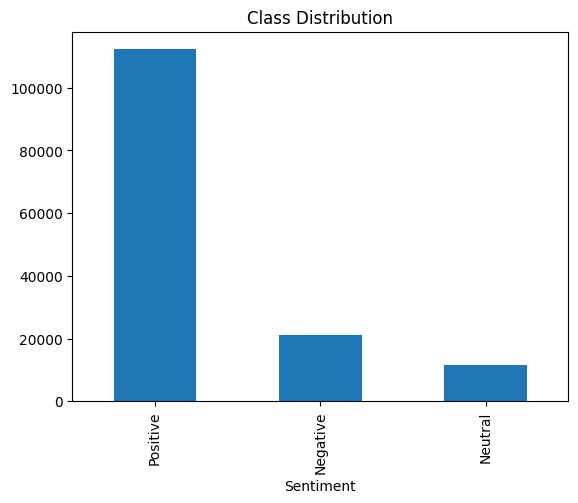

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 86s 25ms/step - accuracy: 0.7718 - loss: 0.6960 - val_accuracy: 0.7782 - val_loss: 0.6689
Epoch 2/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 77s 24ms/step - accuracy: 0.7885 - loss: 0.6119 - val_accuracy: 0.8554 - val_loss: 0.3946
Epoch 3/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.8618 - loss: 0.3814 - val_accuracy: 0.8677 - val_loss: 0.3633
Epoch 4/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - accuracy: 0.8751 - loss: 0.3308 - val_accuracy: 0.8768 - val_loss: 0.3355
Epoch 5/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 83s 22ms/step - accuracy: 0.8932 - loss: 0.2788 - val_accuracy: 0.8762 - val_loss: 0.3464
Epoch 6/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 75s 23ms/step - accuracy: 0.9074 - loss: 0.2418 - val_accuracy: 0.8734 - val_loss: 0.3392
Epoch 7/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - accuracy: 0.9267 - loss: 0.2009 - val_accuracy: 0.8834 - val_loss: 0.3506
Epoch 8/10
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 76s 23ms/step - accuracy: 0.9427 -

In [6]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("amazon_review.csv")

# Use only required columns
df = df[['Text','Score']]

# ==============================
# 3. Convert Score to Sentiment
# ==============================
def convert_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['Score'].apply(convert_sentiment)

# ==============================
# 4. Check Class Balance
# ==============================
class_counts = df['Sentiment'].value_counts()

print("\nClass Distribution:")
print(class_counts)

# Check if dataset is balanced
max_class = class_counts.max()
min_class = class_counts.min()

if max_class > 1.5 * min_class:
    print("\nDataset is UNBALANCED")
else:
    print("\nDataset is BALANCED")

# Plot class distribution
class_counts.plot(kind='bar', title="Class Distribution")
plt.show()

# ==============================
# 5. Encode Labels
# ==============================
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Sentiment'])

# One hot encoding
y = to_categorical(y)

# ==============================
# 6. Text Tokenization
# ==============================
texts = df['Text'].astype(str)

vocab_size = 10000
max_length = 150

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=max_length, padding='post')

# ==============================
# 7. Train Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Build Deep LSTM Model (4 Layers)
# ==============================
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_length))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(32))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ==============================
# 9. Train Model
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# ==============================
# 10. Prediction
# ==============================
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# ==============================
# 11. Precision & Recall
# ==============================
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)

print("\nPrecision for each class:")
for i, label in enumerate(label_encoder.classes_):
    print(label, ":", precision[i])

print("\nRecall for each class:")
for i, label in enumerate(label_encoder.classes_):
    print(label, ":", recall[i])